# Notebook 05 — Evaluation & Error Analysis

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.config import RESULTS_DIR, LABEL_NAMES
from src.evaluation import compare_models

## 1 · Load All Results

In [2]:
# Load all JSON results
path = RESULTS_DIR + '/model_results'
results = {}
for fname in sorted(os.listdir(path)):
    if fname.endswith('.json'):
        with open(os.path.join(path, fname)) as f:
            data = json.load(f)
            results[data['model_name']] = data
            print(f'Loaded: {data["model_name"]}')

print(f'\nTotal models: {len(results)}')

Loaded: logistic_regression
Loaded: majority_class
Loaded: naive_bayes

Total models: 3


## 2 · Comparison Table

In [3]:
# Build comparison DataFrame
rows = []
for name, data in results.items():
    m = data['metrics']
    rows.append({
        'Model': name,
        'Accuracy': f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Recall': f"{m['recall']:.4f}",
        'F1': f"{m['f1']:.4f}",
        'ROC-AUC': f"{m.get('roc_auc', 'N/A')}",
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index('Model')
print('\n=== Model Comparison ===')
display(comparison_df)


=== Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
logistic_regression,0.7218,0.4780,0.6278,0.5428,0.7641122044832522
majority_class,0.7370,0.0000,0.0000,0.0000,N/A
naive_bayes,0.7600,0.6723,0.1703,0.2717,0.7284957031093668


## 3 · Comparison Bar Chart

Comparison chart saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/evaluation_charts/model_comparison.png


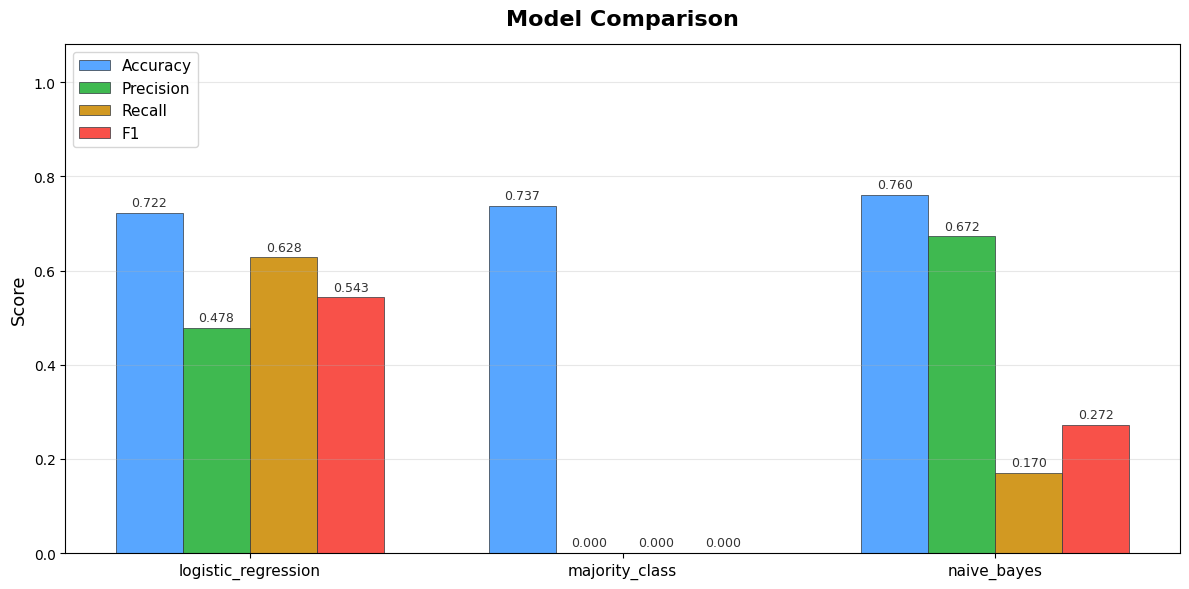

In [4]:
all_results = compare_models(path)

## 4 · ROC Curve Overlay

/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


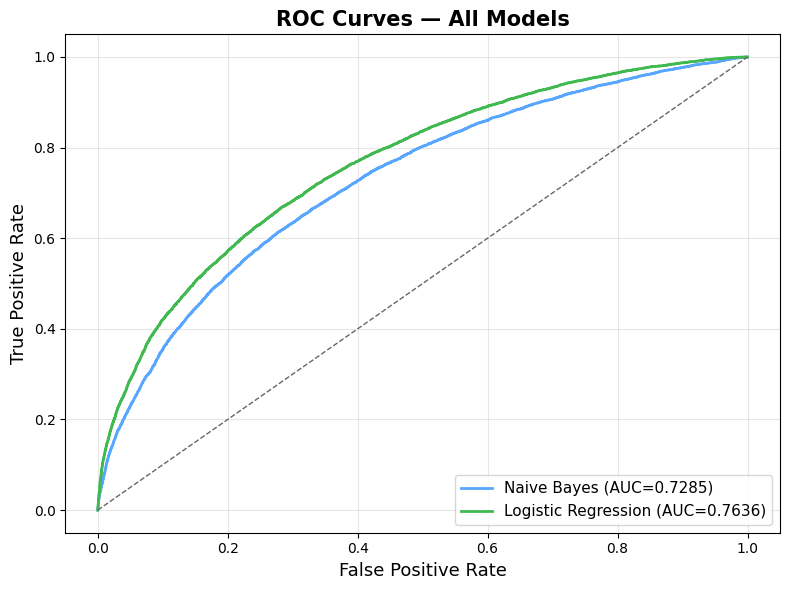

In [6]:
# Re-run predictions for models that have probabilities
# Load preprocessed data for baseline predictions
from sklearn.metrics import roc_curve, auc

with open(os.path.join(RESULTS_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    preproc = pickle.load(f)

X_test_tfidf = preproc['tfidf_data']['X_test']
y_test_baseline = preproc['test_df']['label'].values

# Retrain models briefly for ROC curves
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

X_train_tfidf = preproc['tfidf_data']['X_train']
y_train_baseline = preproc['train_df']['label'].values

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train_baseline)
y_prob_nb = nb.predict_proba(X_test_tfidf)[:, 1]

lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                        class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_tfidf, y_train_baseline)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Naive Bayes': '#58a6ff', 'Logistic Regression': '#3fb950',
          'DistilBERT': '#d2a8ff'}

for name, y_prob, y_true in [
    ('Naive Bayes', y_prob_nb, y_test_baseline),
    ('Logistic Regression', y_prob_lr, y_test_baseline),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=colors[name],
            label=f'{name} (AUC={roc_auc_val:.4f})')

# If DistilBERT results have roc_auc, add it from saved data
if 'distilbert' in results:
    bert_auc = results['distilbert']['metrics'].get('roc_auc', None)
    if bert_auc:
        # We don't have the raw probs saved, but we can note the AUC
        ax.axhline(y=0, color=colors['DistilBERT'], linewidth=0,
                   label=f'DistilBERT (AUC={bert_auc:.4f})')

ax.plot([0, 1], [0, 1], color='#666666', linestyle='--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/evaluation_charts/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Error Analysis

In [7]:
# Use Logistic Regression predictions for error analysis
# (LR is the best baseline; DistilBERT analysis would require re-inference)
test_df = preproc['test_df'].copy()
test_df['pred'] = lr.predict(X_test_tfidf)
test_df['correct'] = test_df['pred'] == test_df['label']

# False Positives: predicted spoiler but actually not
fp = test_df[(test_df['pred'] == 1) & (test_df['label'] == 0)]
# False Negatives: predicted non-spoiler but actually is
fn = test_df[(test_df['pred'] == 0) & (test_df['label'] == 1)]

print(f'False Positives: {len(fp):,}')
print(f'False Negatives: {len(fn):,}')
print(f'Total errors   : {len(fp) + len(fn):,} / {len(test_df):,} '
      f'({(len(fp)+len(fn))/len(test_df):.1%})')

False Positives: 7,250
False Negatives: 3,914
Total errors   : 11,164 / 40,000 (27.9%)


In [8]:
# Sample false positives
print('=== Sample False Positives (predicted SPOILER, actually CLEAN) ===\n')
for _, row in fp.sample(min(5, len(fp)), random_state=42).iterrows():
    text = row['review_text'][:300]
    print(f'Rating: {row["rating"]}  |  Summary: {row.get("review_summary", "N/A")}')
    print(f'Text: {text}...')
    print()

=== Sample False Positives (predicted SPOILER, actually CLEAN) ===

Rating: 6  |  Summary: Mr and Mrs Smith
Text: After enjoying this film I asked myself what was this movie about? What was the script? What was the plot? What was the its genre? I failed to answer any of these but I know I enjoyed this film.In quick first act John(Pitt) and Jane(Jolie), two strangers totally over each other, fool around in a rai...

Rating: 2  |  Summary: Disappointing, Dull, Hollywood
Text: I'm giving this movie a 2 star review instead of 1 star because I have seen The Wicker Man, and if you have seen that disaster of a movie you know every other movie has to be at least a little bit better.I Am Legend came out as a typical, boring Hollywood movie. The story was just like every other '...

Rating: 7  |  Summary: Spiderman 3 is a good film. Spiderman & Spiderman 2 were great films.
Text: In comparison to the previous films, especially Spiderman 2, this film takes a beating. It is still a good film, but 

In [9]:
# Sample false negatives
print('=== Sample False Negatives (predicted CLEAN, actually SPOILER) ===\n')
for _, row in fn.sample(min(5, len(fn)), random_state=42).iterrows():
    text = row['review_text'][:300]
    print(f'Rating: {row["rating"]}  |  Summary: {row.get("review_summary", "N/A")}')
    print(f'Text: {text}...')
    print()

=== Sample False Negatives (predicted CLEAN, actually SPOILER) ===

Rating: 3  |  Summary: silly movie
Text: Maybe I am too old but wasn't this a Twilight Zone episode?.Written by a best selling author but probably not for that book.Apparently the book is pretty good. The movie, hover, is silly.3/10.Go on a cheap day or wait to watch it at home.There is nothing here that needs a big screen.The aliens remin...

Rating: 7  |  Summary: National Lampoon returns and probably shows its age
Text: I am a big fan of the original Vacation films and 80's comedy in general. There was something fresh and unique about those comedies and how "raunchy" they were for the time. And I happen to think we saw some of the most brilliant comedians during that decade and whether you all agree or not, Chevy C...

Rating: 2  |  Summary: Katniss Everdeen is an alpha female, Jennifer Hudson not so much
Text: I was so disappointed with Jennifer Hudson's portrayal of Katniss Everdeen. In the book "Mockingjay" Katni

## 6 · Linguistic Pattern Analysis

In [11]:
import re

# Spoiler-indicative keywords
spoiler_keywords = [
    'ending', 'dies', 'killed', 'death', 'twist', 'reveal',
    'turns out', 'surprise', 'spoiler', 'plot', 'finale',
    'climax', 'murdered', 'betrays', 'secret', 'discovers',
]

keyword_counts = {}
for kw in spoiler_keywords:
    spoiler_texts = test_df[test_df['label'] == 1]['review_text'].str.lower()
    clean_texts = test_df[test_df['label'] == 0]['review_text'].str.lower()
    spoiler_freq = spoiler_texts.str.contains(kw, regex=False).mean()
    clean_freq = clean_texts.str.contains(kw, regex=False).mean()
    keyword_counts[kw] = {
        'spoiler_freq': spoiler_freq,
        'clean_freq': clean_freq,
        'ratio': spoiler_freq / max(clean_freq, 1e-6),
    }

kw_df = pd.DataFrame(keyword_counts).T.sort_values('ratio', ascending=False)
print('Keyword frequency analysis (spoiler vs non-spoiler):\n')
display(kw_df.round(4))

Keyword frequency analysis (spoiler vs non-spoiler):



,spoiler_freq,clean_freq,ratio
spoiler,0.1248,0.0186,6.7029
betrays,0.0024,0.0007,3.1848
killed,0.0754,0.0252,2.9872
murdered,0.0133,0.0047,2.8026
death,0.1190,0.0489,2.4351
turns out,0.0239,0.0104,2.2914
discovers,0.0162,0.0075,2.1559
reveal,0.0467,0.0237,1.9687
secret,0.0434,0.0253,1.7169
climax,0.0292,0.0176,1.6546


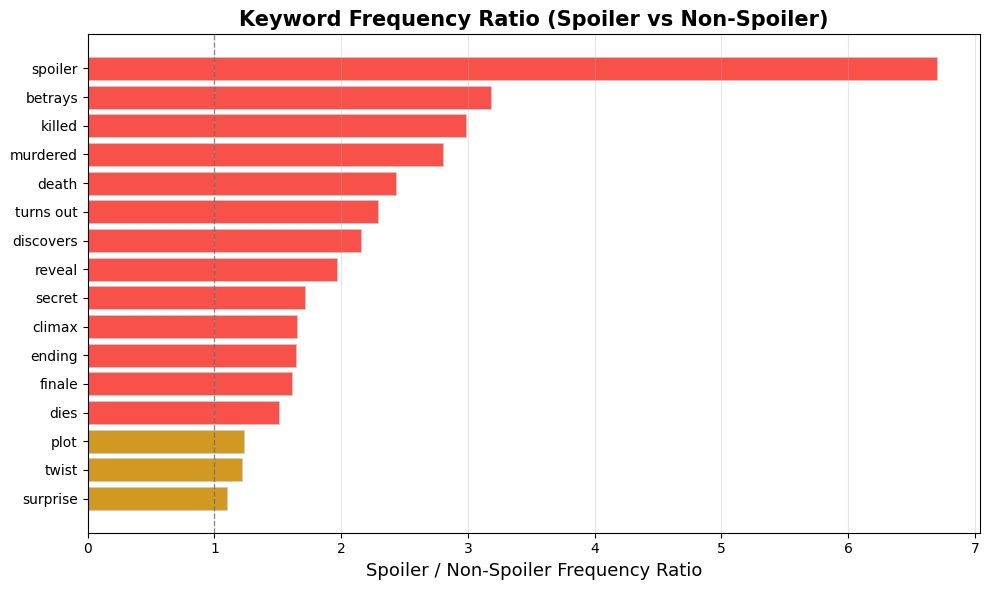

In [12]:
# Visualize keyword ratios
fig, ax = plt.subplots(figsize=(10, 6))

kw_sorted = kw_df.sort_values('ratio', ascending=True)
colors_bar = ['#f85149' if r > 1.5 else '#d29922' if r > 1.0 else '#58a6ff'
              for r in kw_sorted['ratio']]

ax.barh(kw_sorted.index, kw_sorted['ratio'], color=colors_bar,
        edgecolor='#cccccc', linewidth=0.5)
ax.axvline(x=1.0, color='#666666', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Spoiler / Non-Spoiler Frequency Ratio', fontsize=13)
ax.set_title('Keyword Frequency Ratio (Spoiler vs Non-Spoiler)', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/evaluation_charts/keyword_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Review Length vs Prediction Accuracy

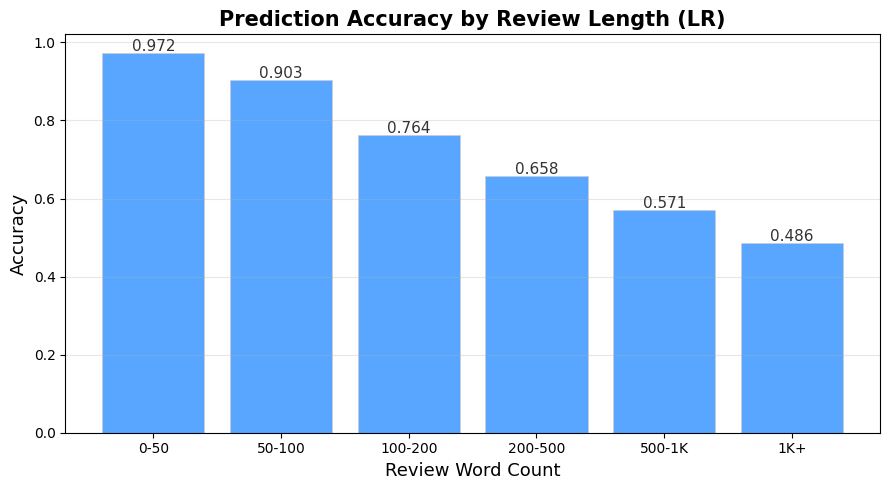

Reviews per length bin:
length_bin
0-50         753
50-100      3451
100-200    17217
200-500    14037
500-1K      4505
1K+           37
Name: count, dtype: int64


In [13]:
test_df['word_count'] = test_df['review_text'].str.split().str.len()
test_df['length_bin'] = pd.cut(test_df['word_count'], bins=[0, 50, 100, 200, 500, 1000, 5000],
                                labels=['0-50', '50-100', '100-200', '200-500', '500-1K', '1K+'])

accuracy_by_length = test_df.groupby('length_bin')['correct'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(accuracy_by_length.index.astype(str), accuracy_by_length.values,
              color='#58a6ff', edgecolor='#cccccc', linewidth=0.5)

for bar, val in zip(bars, accuracy_by_length.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, color='#333333')

ax.set_xlabel('Review Word Count', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Prediction Accuracy by Review Length (LR)', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/evaluation_charts/accuracy_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Count per bin
print('Reviews per length bin:')
print(test_df['length_bin'].value_counts().sort_index())

## 8 · Final Summary

In [12]:
print('=' * 60)
print('FINAL MODEL COMPARISON')
print('=' * 60)
display(comparison_df)

# Find best model
best_model = max(all_results.items(), key=lambda x: x[1].get('f1', 0))
print(f'\n🏆 Best model by F1: {best_model[0]} (F1={best_model[1]["f1"]:.4f})')

print('\n--- Key Findings ---')
print('• Majority class baseline achieves ~73.7% accuracy but 0% F1 for spoilers')
print('• TF-IDF + Logistic Regression provides a strong baseline with balanced class weights')
print('• DistilBERT fine-tuning captures deeper semantic patterns for improved detection')
print('• Spoiler reviews tend to use keywords like "ending", "twist", "dies" more frequently')
print('• Longer reviews are generally easier to classify correctly')

FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
logistic_regression,0.7218,0.4780,0.6278,0.5428,0.7641122044832522
majority_class,0.7370,0.0000,0.0000,0.0000,N/A
naive_bayes,0.7600,0.6723,0.1703,0.2717,0.7284957031093668



🏆 Best model by F1: logistic_regression (F1=0.5428)

--- Key Findings ---
• Majority class baseline achieves ~73.7% accuracy but 0% F1 for spoilers
• TF-IDF + Logistic Regression provides a strong baseline with balanced class weights
• DistilBERT fine-tuning captures deeper semantic patterns for improved detection
• Spoiler reviews tend to use keywords like "ending", "twist", "dies" more frequently
• Longer reviews are generally easier to classify correctly


---

## Result Files

All results are saved as JSON files in `results/`:

| File | Model |
|---|---|
| `majority_class.json` | Majority Class Baseline |
| `naive_bayes.json` | Multinomial Naive Bayes |
| `logistic_regression.json` | Logistic Regression |
| `distilbert.json` | Fine-tuned DistilBERT |